# B1 — Table 4 (profit decomposition) + significance tests

**Produces**: every value of manuscript Table 4 (Bid/Operation/Degradation/Total,
mean & std over 10 seeds), Welch t / one-sample t tests, complete-separation check.

- Every checkpoint is re-evaluated on the 30-day test set in **eval mode
  (dropout OFF)** — this is the basis of the paper's final numbers.
- Coop-DASAC = `results/coop_dasac`, Coop-DABC = `results/coop_dabc` checkpoints.
- MPC row = `results/sensitivity/mpc_components_tol.json` cache (tol=5);
  Expert row = OJPD demonstration replay.
- Runtime: about 1-3 min on CPU.

**Manuscript reference values (this notebook's output must match)**

| Case | Bid | Ope | Deg | Total |
|---|---|---|---|---|
| Single-SAC | 4,235 (138) | 100 (0) | −74 (37) | 4,261 (152) |
| Inde-DASAC | 4,465 (88) | 78 (43) | −88 (19) | 4,455 (54) |
| Coop-DASAC | 4,527 (35) | 139 (23) | −100 (11) | 4,566 (33) |
| Coop-DABC | 5,787 (155) | −694 (151) | −386 (32) | 4,707 (44) |
| MPC | 4,786 | 245 | −574 | 4,456 |
| Expert | 6,731 | −432 | −383 | 5,916 |


In [1]:
import os, sys, json
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

REV  = os.path.abspath(os.path.join(os.getcwd(), ".."))  # repo root
CODE = os.path.join(REV, "code"); sys.path.insert(0, CODE)
RES  = os.path.join(REV, "results")
ANA  = os.path.join(REV, "analysis")


In [2]:
# Re-evaluate the 4 learned methods x 10 seeds in eval mode
from data.settings import Data_Test, idx_val_end
from algorithms.eval_utils import METHODS, evaluate_method, expert_daily

DEG, TOL = 5.0, 5.0
SEEDS = range(10)

per_seed = {}   # method -> (n_seed, 4) per-seed day-means
for name in METHODS:
    a, used = evaluate_method(name, DEG, TOL, Data_Test, SEEDS)
    per_seed[name] = a
    print(f"{name:<12} n={len(a):2d}  Total mean={a[:,3].mean():,.0f}")


Single-SAC   n=10  Total mean=4,261


Inde-DASAC   n=10  Total mean=4,455


Coop-DASAC   n=10  Total mean=4,566


Coop-DABC    n=10  Total mean=4,707


In [3]:
# MPC row (cache) + Expert (OJPD) row (demonstration replay)
mpc = json.load(open(os.path.join(RES, "sensitivity", "mpc_components_tol.json")))["5.0"]
MPC_ROW = [mpc["bid"], mpc["ope"], mpc["deg"], mpc["total"]]

exp = expert_daily(DEG, TOL, Data_Test, idx_val_end)     # (days, 3) = [bid, ope, deg]
EXP_ROW = [exp[:, 0].mean(), exp[:, 1].mean(), exp[:, 2].mean(), exp.sum(1).mean()]
print("MPC   ", [f"{v:,.0f}" for v in MPC_ROW])
print("Expert", [f"{v:,.0f}" for v in EXP_ROW])


[Expert buffer] 30 episodes  tol=5.0MW  deg=$5.0/MWh
[Expert buffer] total_return=177471  buf_bid.size=2880  buf_ope.size=2880
MPC    ['4,786', '245', '-574', '4,456']
Expert ['6,731', '-432', '-383', '5,916']


In [4]:
# Assemble Table 4
def fmt(m, s):
    return f"{m:,.0f} ({s:,.0f})"

rows = []
for name, a in per_seed.items():
    m, s = a.mean(0), a.std(0, ddof=0)
    rows.append([name] + [fmt(m[i], s[i]) for i in range(4)])
rows.append(["MPC"] + [f"{v:,.0f}" for v in MPC_ROW])
rows.append(["Expert (OJPD)"] + [f"{v:,.0f}" for v in EXP_ROW])
table4 = pd.DataFrame(rows, columns=["Case", "Bid", "Operation", "Degradation", "Total"])
table4


,Case,Bid,Operation,Degradation,Total
0,Single-SAC,"4,235 (138)",100 (0),-74 (37),"4,261 (152)"
1,Inde-DASAC,"4,465 (88)",78 (43),-88 (19),"4,455 (54)"
2,Coop-DASAC,"4,527 (35)",139 (23),-100 (11),"4,566 (33)"
3,Coop-DABC,"5,787 (155)",-694 (151),-386 (32),"4,707 (44)"
4,MPC,"4,786",245,-574,"4,456"
5,Expert (OJPD),"6,731",-432,-383,"5,916"


In [5]:
# Significance: stochastic benchmarks = Welch two-sample, deterministic MPC = one-sample (all one-sided, DABC superior)
dabc = per_seed["Coop-DABC"][:, 3]
for name in ["Single-SAC", "Inde-DASAC", "Coop-DASAC"]:
    b = per_seed[name][:, 3]
    t, p2 = stats.ttest_ind(dabc, b, equal_var=False)
    p1 = p2 / 2 if t > 0 else 1 - p2 / 2
    print(f"vs {name:<12} diff={dabc.mean()-b.mean():+7.1f}  Welch t={t:6.2f}  "
          f"p={p1:.2e}  full separation={dabc.min() > b.max()}")
t, p2 = stats.ttest_1samp(dabc, MPC_ROW[3])
p1 = p2 / 2 if t > 0 else 1 - p2 / 2
print(f"vs MPC        diff={dabc.mean()-MPC_ROW[3]:+7.1f}  one-sample t={t:6.2f}  "
      f"p={p1:.2e}  all>MPC={bool((dabc > MPC_ROW[3]).all())}")
print("\nDABC seeds sorted:", np.round(np.sort(dabc)).astype(int).tolist())


vs Single-SAC   diff= +445.8  Welch t=  8.45  p=2.61e-06  full separation=True
vs Inde-DASAC   diff= +251.9  Welch t= 10.80  p=1.99e-09  full separation=True
vs Coop-DASAC   diff= +140.2  Welch t=  7.58  p=4.25e-07  full separation=True
vs MPC        diff= +250.6  one-sample t= 16.92  p=1.97e-08  all>MPC=True

DABC seeds sorted: [4634, 4638, 4665, 4704, 4710, 4713, 4735, 4751, 4752, 4763]


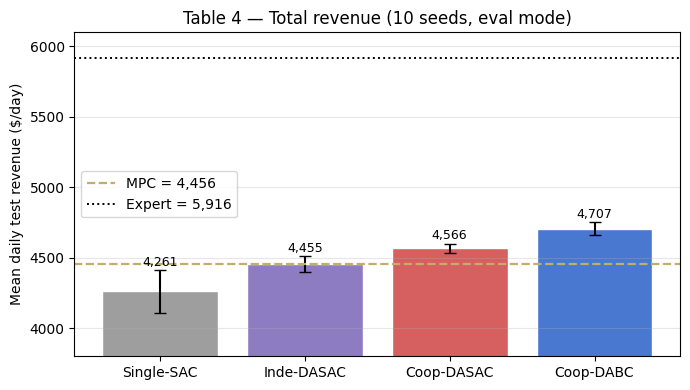

In [6]:
# Plot: total profit (seed-std error bars) + MPC reference line
names = list(per_seed)
means = [per_seed[n][:, 3].mean() for n in names]
stds  = [per_seed[n][:, 3].std(ddof=0) for n in names]
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(names, means, yerr=stds, capsize=4,
       color=["#9E9E9E", "#8E7CC3", "#D65F5F", "#4878CF"], edgecolor="white")
ax.axhline(MPC_ROW[3], ls="--", color="#C4AD66", lw=1.6, label=f"MPC = {MPC_ROW[3]:,.0f}")
ax.axhline(EXP_ROW[3], ls=":",  color="black",   lw=1.4, label=f"Expert = {EXP_ROW[3]:,.0f}")
for i, (m, s) in enumerate(zip(means, stds)):
    ax.text(i, m + s + 30, f"{m:,.0f}", ha="center", fontsize=9)
ax.set_ylabel("Mean daily test revenue ($/day)"); ax.set_ylim(3800, 6100)
ax.grid(axis="y", alpha=0.3); ax.legend()
ax.set_title("Table 4 — Total revenue (10 seeds, eval mode)")
plt.tight_layout(); plt.show()
